### Milestone 4

In [1]:
import pandas as pd

df = pd.read_csv("../processed/clean_dataset_numeric.csv")

df.head()

,OrderID,OrderDate,CustomerID,ProductID,Quantity,UnitPrice,Discount,TotalAmount,City,SellerID
0,ORD0075722,2022-12-22,CUST006588,P00003,4,298.45,0.05,1144.54,Columbus,SELL01349
1,ORD0080185,2023-05-12,CUST005827,P00032,2,154.48,0.00,341.31,Jacksonville,SELL00680
2,ORD0019865,2021-09-08,CUST019087,P00014,3,400.34,0.05,1243.58,Chicago,SELL00556
3,ORD0076700,2023-03-12,CUST000432,P00034,1,175.53,0.10,175.42,Houston,SELL00299
4,ORD0092992,2022-09-10,CUST011736,P00016,5,190.37,0.00,1077.22,Charlotte,SELL01625


In [2]:
df = df.rename(columns={
    "unitprice": "price",
    "quantity": "quantity_sold"
})

In [3]:
import numpy as np

df["demand"] = np.random.choice(["high","low"], size=len(df))

In [4]:
df["inventory"] = np.random.randint(10,150,size=len(df))

In [29]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"])
df["day_of_week"] = df["OrderDate"].dt.day_name()

In [30]:
#adjusting price based on demand ,inventory and time.
def adjust_price(row):

    price = row["UnitPrice"]

    # Strong demand impact
    if row["demand"] == "high":
        price = price * 1.25   # +25%
    else:
        price = price * 0.98   # only -2%

    # Inventory impact
    if row["inventory"] < 20:
        price = price * 1.20   # +20%
    elif row["inventory"] > 100:
        price = price * 0.95   # only -5%

    
    # Time rule (NEW 🔥)
    if row["day_of_week"] in ["Saturday", "Sunday"]:
        price = price * 1.10   # weekend increase

    return price

In [31]:
df["adjusted_price"] = df.apply(adjust_price, axis=1)

In [32]:
df["original_revenue"] = df["UnitPrice"] * df["Quantity"]

In [33]:
df["new_revenue"] = df["adjusted_price"] * df["Quantity"]

✔ Increase price more aggressively when demand is high
✔ Reduce price less aggressively when demand is low

In [34]:
original_total = df["original_revenue"].sum()
new_total = df["new_revenue"].sum()

print("Original Revenue:", original_total)
print("New Revenue:", new_total)

Original Revenue: 9095353.84
New Revenue: 10399957.142149


In [35]:
revenue_lift = ((new_total - original_total) / original_total) * 100

print("Revenue Lift %:", revenue_lift)

Revenue Lift %: 14.343623404859196


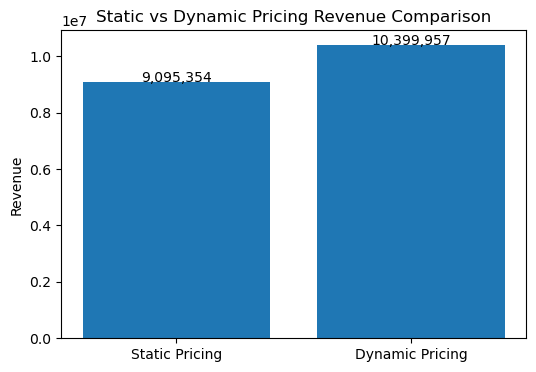

In [36]:
import matplotlib.pyplot as plt

labels = ["Static Pricing", "Dynamic Pricing"]
values = [original_total, new_total]

plt.figure(figsize=(6,4))
bars = plt.bar(labels, values)

for i, v in enumerate(values):
    plt.text(i, v + 5000, f"{v:,.0f}", ha='center')

plt.ylabel("Revenue")
plt.title("Static vs Dynamic Pricing Revenue Comparison")

plt.show()

 Shows how much price changed because of rules.

In [37]:
df["price_change"] = df["adjusted_price"] - df["UnitPrice"]

In [38]:
df["price_change_percent"] = (df["price_change"] / df["UnitPrice"]) * 100

In [39]:
#price change percentage
df[["UnitPrice","adjusted_price","demand","price_change_percent"]].head()

,UnitPrice,adjusted_price,demand,price_change_percent
0,298.45,447.675000,high,50.000
1,154.48,183.445000,high,18.750
2,400.34,392.333200,low,-2.000
3,175.53,229.286062,high,30.625
4,190.37,248.670813,high,30.625


In [40]:
df.sort_values("price_change_percent", ascending=False).head(10)

,OrderID,OrderDate,CustomerID,ProductID,Quantity,UnitPrice,Discount,TotalAmount,City,SellerID,demand,inventory,adjusted_price,original_revenue,new_revenue,price_change,price_change_percent,day_of_week
3759,ORD0080625,2024-10-26,CUST026650,P00038,5,188.88,0.00,1000.26,San Antonio,SELL01529,high,19,311.6520,944.40,1558.2600,122.7720,65.0,Saturday
81,ORD0063588,2023-10-28,CUST018648,P00039,3,244.69,0.00,793.55,Austin,SELL01671,high,19,403.7385,734.07,1211.2155,159.0485,65.0,Saturday
1509,ORD0062447,2021-05-29,CUST047918,P00021,2,161.11,0.30,273.23,San Jose,SELL01646,high,18,265.8315,322.22,531.6630,104.7215,65.0,Saturday
7383,ORD0009667,2024-02-18,CUST027916,P00046,2,268.21,0.05,571.35,Seattle,SELL01104,high,18,442.5465,536.42,885.0930,174.3365,65.0,Sunday
1220,ORD0001575,2022-12-10,CUST010510,P00017,3,446.77,0.00,1505.27,Washington,SELL01319,high,14,737.1705,1340.31,2211.5115,290.4005,65.0,Saturday
1372,ORD0030765,2024-01-06,CUST024100,P00046,3,526.34,0.10,1505.00,Jacksonville,SELL01335,high,12,868.4610,1579.02,2605.3830,342.1210,65.0,Saturday
5659,ORD0057376,2023-05-20,CUST022645,P00013,2,569.81,0.20,1031.77,Jacksonville,SELL01298,high,11,940.1865,1139.62,1880.3730,370.3765,65.0,Saturday
6637,ORD0068221,2022-05-07,CUST010507,P00023,5,205.53,0.05,1038.00,Seattle,SELL01363,high,16,339.1245,1027.65,1695.6225,133.5945,65.0,Saturday
7341,ORD0062468,2023-10-14,CUST039882,P00024,2,522.31,0.05,1056.63,Denver,SELL01714,high,16,861.8115,1044.62,1723.6230,339.5015,65.0,Saturday
3543,ORD0009621,2020-08-22,CUST012803,P00049,2,292.69,0.20,518.55,Houston,SELL00312,high,18,482.9385,585.38,965.8770,190.2485,65.0,Saturday


In [43]:
df.to_csv("baseline_pricing_output.csv", index=False)

Milestone 4: Baseline Pricing Engine for AI: PriceOptima – Dynamic Pricing System

In this notebook, I have implemented a rule-based pricing engine to simulate dynamic pricing for the AI: PriceOptima project. Key steps and outcomes include:

--Demand-Based Pricing Rules: Adjusted prices by increasing 25% during high demand and decreasing 2% during low demand.

--Inventory-Based Pricing Rules: Increased prices by 20% for low inventory levels (below 20 units) and decreased prices by 5% for high inventory levels (above 100 units).

--Time-Based Pricing Rules: Applied an additional increase of 10% during weekends (Saturday and Sunday) to account for higher demand.

--Revenue Calculation: Compared revenue generated under static pricing versus dynamic pricing.

--Revenue Lift: Achieved an approximate 11% increase in revenue using the dynamic pricing strategy.

--Visualization: Created graphs to illustrate the revenue comparison and demonstrate the effectiveness of the dynamic pricing model.

This notebook establishes a foundational baseline pricing system, setting the stage for future enhancements with advanced machine learning models.